### Using web crawling techniques, analyse the internal and external link structure of a website. Create a graph of the website's hyperlink structure and identify key pages using PageRank or HITS algorithm.

Pages visited: 20
Internal links found: 5796
External links found: 199
Graph nodes: 1617
Graph edges: 5796

--- Top 5 Pages by PageRank ---
https://www.manipal.edu/mu.html: 0.0007
https://www.manipal.edu/mit/program-list/btech/btech-aeronautical-engineering.html: 0.0007
https://www.manipal.edu/mu/news-events/kmc-manipal-moves-up--mcops-retains-place-in-qs-world-ranking-by.html: 0.0007
https://www.manipal.edu/mu/news-events.html: 0.0007
https://www.manipal.edu/mu/news-events/-bad-practice-in-medicine-must-be-rooted-out---world-medical-edu.html: 0.0007


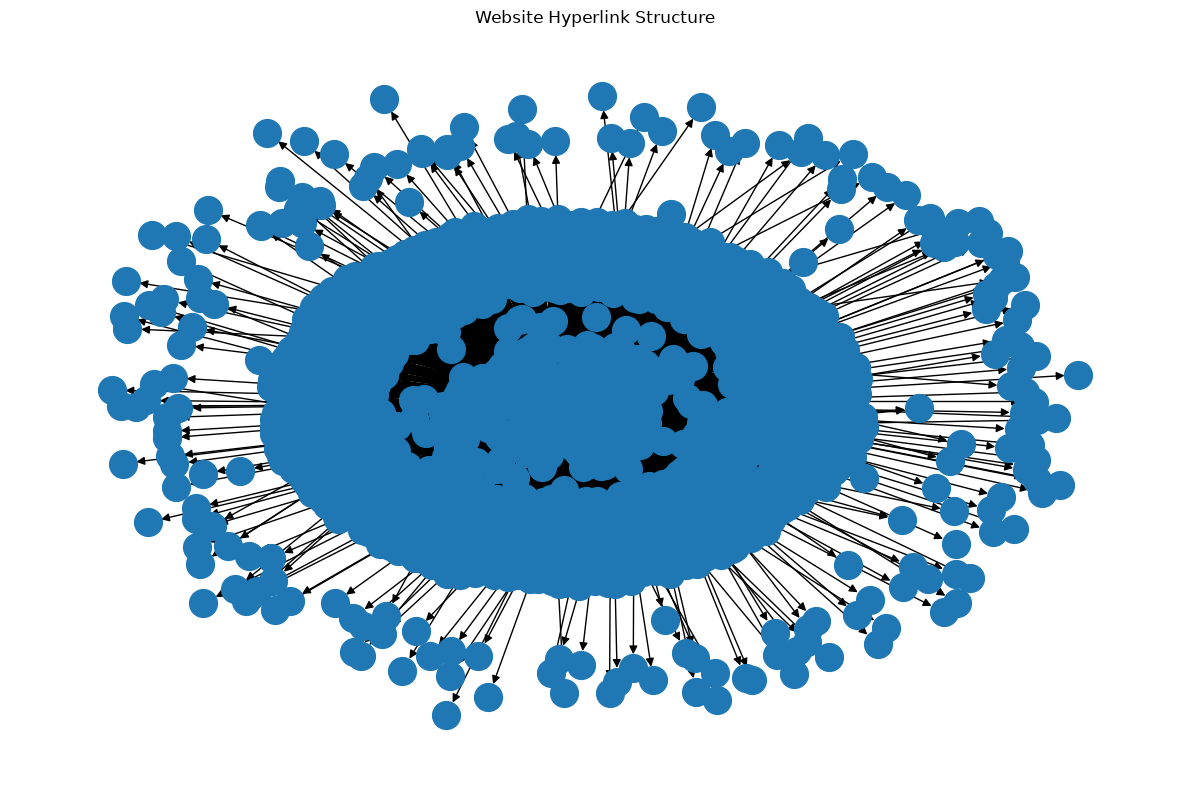

In [2]:
import requests
import networkx as nx
import matplotlib.pyplot as plt
import tldextract

from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse, urldefrag

# 1. Website to crawl
start_url = "https://www.manipal.edu/mit.html"
max_pages = 20

# 2. Identify the main domain
def get_domain(url):
    ext = tldextract.extract(url)
    return ext.top_domain_under_public_suffix

main_domain = get_domain(start_url)

# 3. Crawl the website
def crawl_website(start_url, max_pages=20):
    visited = set()
    internal_links = set()
    external_links = set()
    to_visit = [start_url]

    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})

    while to_visit and len(visited) < max_pages:
        url = to_visit.pop(0)
        url = urldefrag(url)[0]

        if url in visited:
            continue

        visited.add(url)

        try:
            response = session.get(url, timeout=10)
            response.raise_for_status()

            # Skip non-HTML content
            content_type = response.headers.get("Content-Type", "")
            if "text/html" not in content_type:
                continue

            soup = BeautifulSoup(response.text, "html.parser")

            for link in soup.find_all("a", href=True):
                href = link["href"].strip()
                full_url = urljoin(url, href)
                full_url = urldefrag(full_url)[0]

                parsed = urlparse(full_url)

                # Ignore non-web links such as mailto: and javascript:
                if parsed.scheme not in ("http", "https"):
                    continue

                # Remove query strings for simpler graph representation
                full_url = parsed._replace(
                    query="", fragment=""
                ).geturl().rstrip("/")

                if get_domain(full_url) == main_domain:
                    internal_links.add((url.rstrip("/"), full_url))

                    if full_url not in visited and full_url not in to_visit:
                        if len(visited) + len(to_visit) < max_pages:
                            to_visit.append(full_url)
                else:
                    external_links.add((url.rstrip("/"), full_url))

        except requests.RequestException as e:
            print(f"Skipping {url}: {e}")

    return visited, internal_links, external_links


visited, internal_links, external_links = crawl_website(
    start_url, max_pages
)

# 4. Display crawling results
print("Pages visited:", len(visited))
print("Internal links found:", len(internal_links))
print("External links found:", len(external_links))

# 5. Create a directed graph of internal links
G = nx.DiGraph()
G.add_edges_from(internal_links)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

# 6. Calculate PageRank
if G.number_of_nodes() > 0:
    pagerank = nx.pagerank(G, alpha=0.85)

    top_pages = sorted(
        pagerank.items(),
        key=lambda item: item[1],
        reverse=True
    )[:5]

    print("\n--- Top 5 Pages by PageRank ---")
    for page, score in top_pages:
        print(f"{page}: {score:.4f}")

    # 7. Visualize the hyperlink graph
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5, seed=42)

    nx.draw_networkx(
        G,
        pos,
        with_labels=False,
        node_size=400,
        arrows=True,
        arrowsize=12
    )

    plt.title("Website Hyperlink Structure")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No internal-link graph was created. Try another website URL.")